In [1]:
import numpy as np
from src.true_sample_and_sketch import Sample_and_sketch
from src.simhash import SH
import matplotlib.pyplot as plt

def PCA_rotation(X):
    X_centered = X
    cov_matrix = np.cov(X_centered.T)

    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

    idx = eigenvalues.argsort()[::-1]
    eigenvectors = eigenvectors[:, idx]

    X_rotated = np.dot(X_centered, eigenvectors)
    
    return X_rotated, np.mean(X, axis=0), np.float128(eigenvectors)

def test_PCA_rotation(X, q, iterations, num_vectors):
    X_rot, mu, rot_mat = PCA_rotation(X)
    print("pca done")
    errors_usual = []
    errors_pca = []
    errors_sh = []
    for i in [256, 512, 1024, 2048, 4096]:
        error_usual = 0
        error_pca = 0
        error_sh = 0
        for j in range(0, iterations):
            sk = Sample_and_sketch(int(0.5 * i), SH, int(0.5 * i), j, dim = len(X[0]))
            sk_sh = Sample_and_sketch(i, SH, 0, j, dim=len(X[0]))
            q_rot = rot_mat @ q
            q_sketch = sk.sketch(q)
            q_sketch_pca = sk.sketch(q_rot)
            q_sketch_sh = sk_sh.sketch(q)
            for k in range(0, num_vectors):
                vec_sketch = sk.sketch(X[k])
                vec_pca_sketch = sk.sketch(X_rot[k])
                vec_sh_sketch = sk_sh.sketch(X[k])
                ip = X[k] @ q

                error_usual += np.abs(q_sketch.inner_product(vec_sketch) - ip) / (np.linalg.norm(q) * np.linalg.norm(X[k]))
                error_pca += np.abs((q_sketch_pca.inner_product(vec_pca_sketch) - ip)) / (np.linalg.norm(q) * np.linalg.norm(X[k]))
                error_sh += np.abs((q_sketch_sh.inner_product(vec_sh_sketch)) - ip) / (np.linalg.norm(q) * np.linalg.norm(X[k]))
            
        errors_usual.append(error_usual / (iterations * num_vectors))
        errors_pca.append(error_pca / (iterations * num_vectors))
        errors_sh.append(error_sh / (iterations * num_vectors))

    print("Normal")
    print(errors_usual)
    print("PCA")
    print(errors_pca)
    print("SH")
    print(errors_sh)

def test_rotation(X, q, iterations, num_vectors, rot_mat):

    errors_usual = []
    errors_pca = []
    errors_sh = []
    print("mat_mul done")

    for i in [256, 512, 1024, 2048, 4096]:
        error_usual = 0
        error_pca = 0
        error_sh = 0
        for j in range(0, iterations):
            sk = Sample_and_sketch(int(0.5 * i), SH, int(0.5 * i), j, dim = len(X[0]))
            sk_sh = Sample_and_sketch(i, SH, 0, j, dim=len(X[0]))
            q_rot = rot_mat @ q
            q_sketch = sk.sketch(q)
            q_sketch_pca = sk.sketch(q_rot)
            q_sketch_sh = sk_sh.sketch(q)
            for k in range(1, num_vectors + 1):
                X_rot = rot_mat @ X[k]
                vec_sketch = sk.sketch(X[k])
                vec_pca_sketch = sk.sketch(X_rot)
                vec_sh_sketch = sk_sh.sketch(X[k])
                ip = X[k] @ q

                error_usual += np.abs(q_sketch.inner_product(vec_sketch) - ip) / (np.linalg.norm(q) * np.linalg.norm(X[k]))
                error_pca += np.abs(q_sketch_pca.inner_product(vec_pca_sketch) - ip) / (np.linalg.norm(q) * np.linalg.norm(X[k]))
                error_sh += np.abs((q_sketch_sh.inner_product(vec_sh_sketch)) - ip) / (np.linalg.norm(q) * np.linalg.norm(X[k]))
        
        print("size_done")
        errors_usual.append(error_usual / (iterations * num_vectors))
        errors_pca.append(error_pca / (iterations * num_vectors))
        errors_sh.append(error_sh / (iterations * num_vectors))

    print("Normal")
    print(errors_usual)
    print("PCA")
    print(errors_pca)
    print("SH")
    print(errors_sh)


import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import issparse

def plot_mass(vec):
    """
    Plots cumulative mass concentration, ignoring zero-valued dimensions.
    Works with both NumPy arrays and Scipy sparse vectors.
    """
    # 1. Extract non-zero entries
    if issparse(vec):
        # Scipy sparse objects store non-zeros in the .data attribute
        data = np.abs(vec.data)
    else:
        # For numpy, filter out zeros and take absolute values
        data = np.abs(vec[vec != 0])
    
    if len(data) == 0:
        print("Vector is empty or contains only zeros.")
        return

    # 2. Sort descending to show concentration
    sorted_data = np.sort(data)[::-1]
    
    # 3. Calculate cumulative percentage
    cumulative_sum = np.cumsum(sorted_data)
    total_mass = cumulative_sum[-1]
    percentages = (cumulative_sum / total_mass) * 100
    
    # 4. Plotting
    plt.figure(figsize=(9, 5))
    # x-axis goes from 1 to the number of non-zero elements
    x_axis = np.arange(1, len(data) + 1)
    
    plt.plot(x_axis, percentages, marker='o', markersize=4, color='#2c3e50')
    
    # Formatting
    plt.title(f'Mass Concentration (Non-zero entries: {len(data)})')
    plt.xlabel('Rank of Entry (k-th largest)')
    plt.ylabel('Percentage of Total Mass (%)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.ylim(0, 105)
    
    # Annotate the "elbow" if it's very concentrated
    plt.tight_layout()
    plt.show()






In [31]:
np.random.seed(42)
n_samples = 20000
n_features = 10000
true_signal = np.random.normal(0, 10, (n_samples, 10)) 
noise = np.random.normal(0, 1, (n_samples, n_features - 10))
X = np.hstack([true_signal, noise])

'''
random_rotation = np.random.randn(n_features, n_features)
Q, _ = np.linalg.qr(random_rotation) # Create a random orthogonal matrix
X = np.dot(X, Q)
'''


'\nrandom_rotation = np.random.randn(n_features, n_features)\nQ, _ = np.linalg.qr(random_rotation) # Create a random orthogonal matrix\nX = np.dot(X, Q)\n'

In [32]:
from sklearn.decomposition import PCA, TruncatedSVD

tsvd = TruncatedSVD(n_components=len(X[0]))
rotated_vectors = tsvd.fit_transform(X)

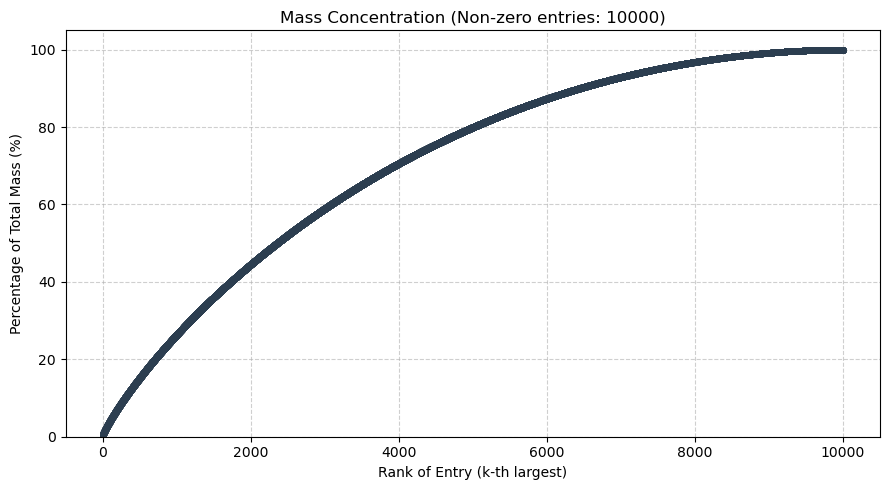

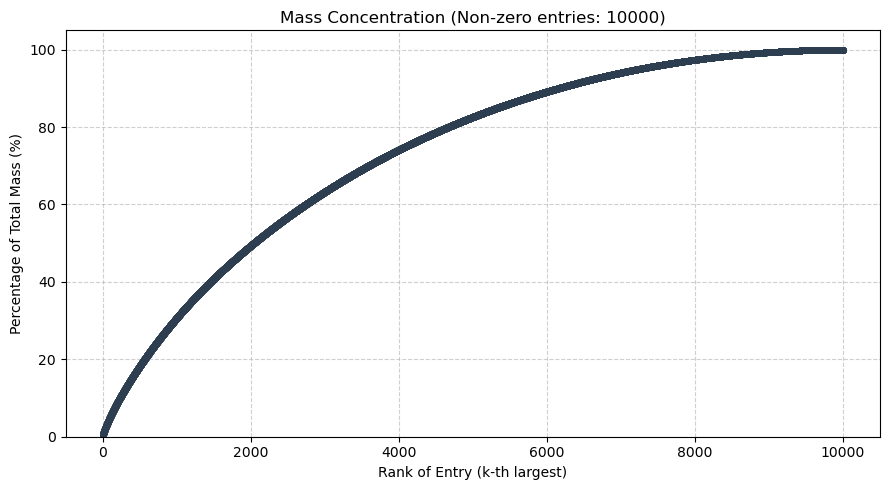

-386.56936785166135
-0.00012301180921323802
-386.56936785166056
10000


In [33]:
plot_mass(X[0])
plot_mass(rotated_vectors[0])

print(X[0] @ X[1])
print(np.mean(X))
print((rotated_vectors[0]) @ (rotated_vectors[1]))
print(len(rotated_vectors[0]))

In [55]:
from src.simhash import SH
from src.true_sample_and_sketch import Sample_and_sketch

def test_vectors(arrays, query, num_arrays, iterations):
    errors_sas = []
    errors_sh = []    
    for size in [256, 512, 1024, 2048, 4096, 8128]:
        error_sas = 0
        error_sh = 0
        for i in range(0, iterations):
            sk1 = Sample_and_sketch(int(0.5 * size), SH, int(0.5 * size), i, dim = len(arrays[0]))
            sk2 = SH(size, i) 
            q_sketch1 = sk1.sketch(query)
            q_sketch2 = sk2.sketch(query)
            for j in range(1, num_arrays + 1):
                vec = arrays[j]
                vec_sas = sk1.sketch(vec)
                vec_sh = sk2.sketch(vec)

                error_sas += np.abs(vec_sas.inner_product(q_sketch1) - query @ vec) / (np.linalg.norm(query) * np.linalg.norm(vec))
                error_sh += np.abs(vec_sh.inner_product(q_sketch2) - query @ vec) / (np.linalg.norm(query) * np.linalg.norm(vec))
        
        errors_sas.append(error_sas / (iterations * num_arrays))
        errors_sh.append(error_sh / (iterations * num_arrays))
    
    print(errors_sas)
    print(errors_sh)



In [34]:
test_vectors(X, X[0], 10, 10)

[0.10762818658735604, 0.07745938969114592, 0.055051245454156926, 0.03675387316212147]
[0.07583032619809256, 0.059977993835774776, 0.04049055028005083, 0.029661257308406894]


In [35]:
test_vectors(rotated_vectors, rotated_vectors[0], 10, 10)

[0.10687489179426021, 0.07719266831532919, 0.05839806644117374, 0.03620013128443832]
[0.07675352765010855, 0.05682384368932851, 0.03436244492910391, 0.02508153975237902]


In [59]:
import pickle

with open('data/matryoshka.pkl', 'rb') as f:
    arrays = pickle.load(f)

In [58]:
test_vectors(arrays, arrays[0], 10, 10)

[0.0657613483409636, 0.05533863415475089, 0.04447352991632373, 0.02969208572263682, 0.01981020687307503, 0.013716145124156101]
[0.050211406894184074, 0.04056040511084911, 0.02500507817238262, 0.019552508044616973, 0.013710030053263253, 0.010001499745029669]


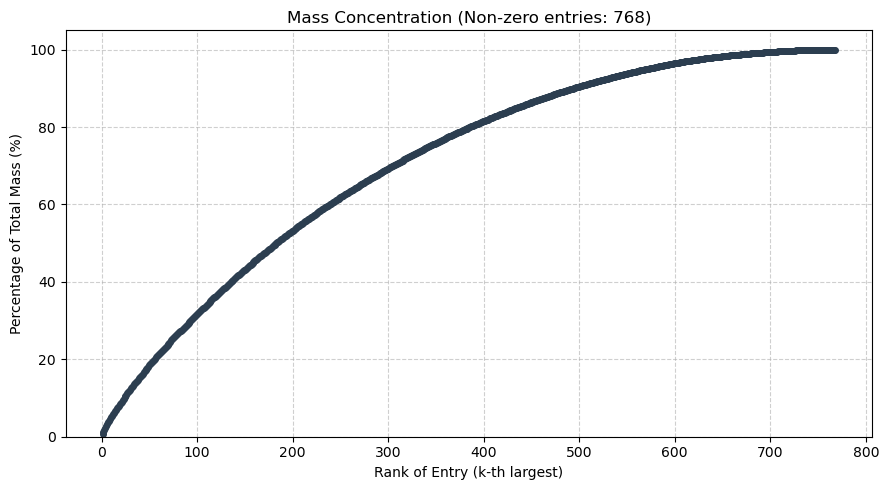

302.9903


In [66]:
plot_mass(arrays[0])
print(arrays[0] @ arrays[1])

In [67]:
tsvd = TruncatedSVD(n_components=len(arrays[0]))
rotated_vectors = tsvd.fit_transform(arrays)

In [68]:
test_vectors(rotated_vectors, rotated_vectors[0], 10, 10)

[0.08382143645426149, 0.0514611910093192, 0.04129843192699928, 0.023974024186525337, 0.010977000889744726, 0.005772686025364754]
[0.0601252469153076, 0.04140462853368449, 0.02754627627492307, 0.01873328264446629, 0.011298912239203162, 0.00976666522990448]


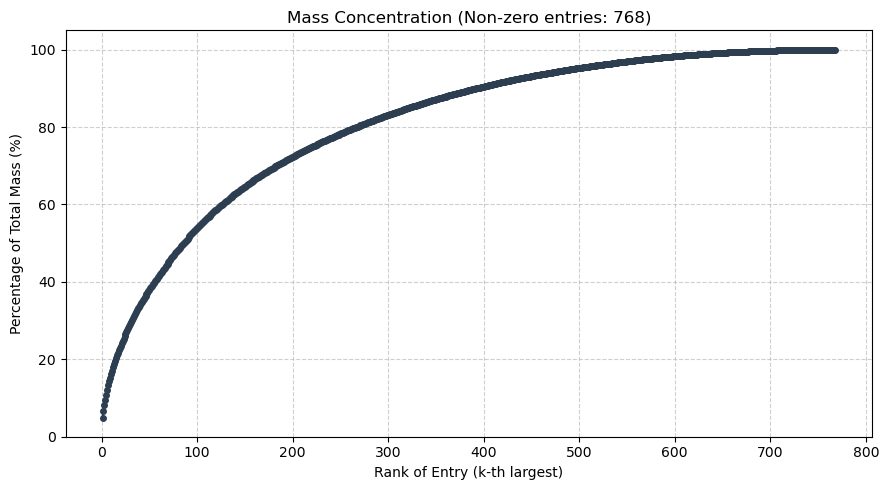

302.99008


In [69]:
plot_mass(rotated_vectors[0])
print(rotated_vectors[0] @ rotated_vectors[1])